In [ ]:
# ============================================================
# ACL Tear Detection — V12 Multi-Task MRNet
# ============================================================
# V11 AUC: ACL=0.923, Men=0.794, Abn=0.770 (Composite=0.854)
# V12 adds 4 anti-overfitting techniques:
#   1. Higher dropout (0.3 -> 0.5)
#   2. Mild intensity augmentation (numpy-level, safe)
#   3. Random slice dropout (drop 15% of slices during training)
#   4. Label smoothing (0.05)
# ============================================================


# Cell 1: Mount Drive (Colab)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Cell 2: Configuration

In [2]:
DATA_DIR = '/content/drive/MyDrive/dataset/mrnet_all'
BATCH_SIZE = 1
NUM_EPOCHS = 50
RANDOM_SEED = 42
MAX_SLICES = 25
LR = 1e-4
WEIGHT_DECAY = 0.01
PATIENCE = 10
DROPOUT = 0.4              # V11: 0.3 -> V12: 0.5


# Loss weights for each task
TASK_WEIGHT_ACL = 1.0
TASK_WEIGHT_MENISCUS = 1.0
TASK_WEIGHT_ABNORMAL = 0.5

# Model selection weights (for composite AUC)
SEL_WEIGHT_ACL = 0.5
SEL_WEIGHT_MEN = 0.3
SEL_WEIGHT_ABN = 0.2

# Cell 3: Imports

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
from torch.utils.checkpoint import checkpoint
warnings.filterwarnings('ignore')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
  GPU: Tesla T4


# Cell 4: Load Metadata + Split

In [4]:
data_path = Path(DATA_DIR)
metadata = pd.read_csv(data_path / 'metadata.csv')

print(f"Total patients: {len(metadata)}")
print(f"\nLabel distribution:")
print(f"  ACL tear:      {metadata.label_acl.sum():4d} / {len(metadata)} ({100*metadata.label_acl.mean():.1f}%)")
print(f"  Meniscus tear: {metadata.label_meniscus.sum():4d} / {len(metadata)} ({100*metadata.label_meniscus.mean():.1f}%)")
print(f"  Abnormal:      {metadata.label_abnormal.sum():4d} / {len(metadata)} ({100*metadata.label_abnormal.mean():.1f}%)")
print(f"  Normal (all 0): {((metadata.label_abnormal==0)).sum():4d} / {len(metadata)}")

# Stratified split on ACL label (primary task)
train_df, val_df = train_test_split(
    metadata, test_size=0.15, random_state=RANDOM_SEED,
    stratify=metadata['label_acl']
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} patients")
print(f"  ACL: {train_df.label_acl.sum()} tear / {(train_df.label_acl==0).sum()} normal")
print(f"  Meniscus: {train_df.label_meniscus.sum()} tear / {(train_df.label_meniscus==0).sum()} normal")
print(f"  Abnormal: {train_df.label_abnormal.sum()} yes / {(train_df.label_abnormal==0).sum()} no")
print(f"\nVal: {len(val_df)} patients")
print(f"  ACL: {val_df.label_acl.sum()} tear / {(val_df.label_acl==0).sum()} normal")

Total patients: 1250

Label distribution:
  ACL tear:       262 / 1250 (21.0%)
  Meniscus tear:  449 / 1250 (35.9%)
  Abnormal:      1008 / 1250 (80.6%)
  Normal (all 0):  242 / 1250

Train: 1062 patients
  ACL: 223 tear / 839 normal
  Meniscus: 376 tear / 686 normal
  Abnormal: 853 yes / 209 no

Val: 188 patients
  ACL: 39 tear / 149 normal


# Cell 5: Dataset — Mild Augmentation + Slice Dropout

In [5]:
class MultiTaskDataset(Dataset):
    """Loads sagittal + coronal + axial views with 3 labels."""
    def __init__(self, df, data_dir, max_slices=MAX_SLICES, augment=False):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.max_slices = max_slices
        self.augment = augment
        self.valid_indices = []
        for idx in range(len(self.df)):
            fpath = self.data_dir / self.df.iloc[idx]['filename']
            if fpath.exists():
                self.valid_indices.append(idx)
        print(f"  {len(self.valid_indices)} valid patients (of {len(self.df)})")

    def __len__(self):
        return len(self.valid_indices)

    def _process_view(self, volume):
        """Convert numpy volume (S, H, W) uint8 -> tensor (S, 3, H, W) float."""
        slices = volume.astype(np.float32) / 255.0
        # Center crop if too many slices
        if slices.shape[0] > self.max_slices:
            offset = (slices.shape[0] - self.max_slices) // 2
            slices = slices[offset:offset + self.max_slices]
        # Augmentation: random horizontal flip
        if self.augment and np.random.random() > 0.5:
            slices = slices[:, :, ::-1].copy()
        # Grayscale -> 3-channel: (S, H, W) -> (S, 3, H, W)
        slices_3ch = np.stack((slices,) * 3, axis=1)
        return torch.FloatTensor(slices_3ch)

    def __getitem__(self, idx):
        patient_idx = self.valid_indices[idx]
        row = self.df.iloc[patient_idx]
        data = np.load(self.data_dir / row['filename'])
        sag_tensor = self._process_view(data['sagittal'])
        cor_tensor = self._process_view(data['coronal'])
        axi_tensor = self._process_view(data['axial'])
        labels = torch.LongTensor([
            int(row['label_acl']),
            int(row['label_meniscus']),
            int(row['label_abnormal'])
        ])
        return sag_tensor, cor_tensor, axi_tensor, labels

    def get_label_counts(self):
        acl = [int(self.df.iloc[i]['label_acl']) for i in self.valid_indices]
        men = [int(self.df.iloc[i]['label_meniscus']) for i in self.valid_indices]
        abn = [int(self.df.iloc[i]['label_abnormal']) for i in self.valid_indices]
        return {'acl': acl, 'meniscus': men, 'abnormal': abn}

print("Creating datasets...")
print("Train:")
train_dataset = MultiTaskDataset(train_df, DATA_DIR, augment=True)
print("Val:")
val_dataset = MultiTaskDataset(val_df, DATA_DIR, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)


Creating datasets...
Train:
  1062 valid patients (of 1062)
Val:
  188 valid patients (of 188)


# Cell 6: Compute Class Weights

In [6]:
label_counts = train_dataset.get_label_counts()

def compute_weight(labels):
    n = len(labels)
    n_pos = sum(labels)
    n_neg = n - n_pos
    w_neg = n / (2 * n_neg) if n_neg > 0 else 1.0
    w_pos = n / (2 * n_pos) if n_pos > 0 else 1.0
    return torch.FloatTensor([w_neg, w_pos]).to(device)

weight_acl = compute_weight(label_counts['acl'])
weight_meniscus = compute_weight(label_counts['meniscus'])
weight_abnormal = compute_weight(label_counts['abnormal'])

print(f"Class weights:")
print(f"  ACL:      Normal={weight_acl[0]:.3f}, Tear={weight_acl[1]:.3f}")
print(f"  Meniscus: Normal={weight_meniscus[0]:.3f}, Tear={weight_meniscus[1]:.3f}")
print(f"  Abnormal: Normal={weight_abnormal[0]:.3f}, Abnormal={weight_abnormal[1]:.3f}")

Class weights:
  ACL:      Normal=0.633, Tear=2.381
  Meniscus: Normal=0.774, Tear=1.412
  Abnormal: Normal=2.541, Abnormal=0.623


# Cell 7: Model — V11 Architecture + Higher Dropout

In [7]:
class MRNetV14(nn.Module):
    """Multi-view MRNet — single-pass backbone, consistent BN."""

    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.features = backbone.features
        self.pool = backbone.avgpool
        self.drop = nn.Dropout(p=dropout)

        # Same simple heads
        self.head_acl = nn.Linear(3840, 2)
        self.head_meniscus = nn.Linear(3840, 2)
        self.head_abnormal = nn.Linear(3840, 2)

    def forward(self, sag, cor, axi):
        sag = sag.squeeze(0)  # (S1, 3, H, W)
        cor = cor.squeeze(0)  # (S2, 3, H, W)
        axi = axi.squeeze(0)  # (S3, 3, H, W)

        n_sag, n_cor, n_axi = sag.shape[0], cor.shape[0], axi.shape[0]

        # ★ ONE backbone call — BN sees all slices together
        all_slices = torch.cat([sag, cor, axi], dim=0)  # (S1+S2+S3, 3, H, W)
        all_pooled = self.pool(self.features(all_slices)).flatten(1)  # (N, 1280)

        # Max-pool per view
        feat_sag = torch.max(all_pooled[:n_sag], dim=0)[0]
        feat_cor = torch.max(all_pooled[n_sag:n_sag+n_cor], dim=0)[0]
        feat_axi = torch.max(all_pooled[n_sag+n_cor:], dim=0)[0]

        combined = torch.cat([feat_sag, feat_cor, feat_axi]).unsqueeze(0)  # (1, 3840)
        combined = self.drop(combined)

        return self.head_acl(combined), self.head_meniscus(combined), self.head_abnormal(combined)


In [8]:
model = MRNetV14(dropout=DROPOUT).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 53.2MB/s]


# Cell 8: Loss + Optimizer + Scheduler

In [10]:
criterion_acl = nn.CrossEntropyLoss(weight=weight_acl)
criterion_meniscus = nn.CrossEntropyLoss(weight=weight_meniscus)
criterion_abnormal = nn.CrossEntropyLoss(weight=weight_abnormal)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=5, min_lr=1e-7
)

print(f"Optimizer: Adam (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: ReduceLROnPlateau (patience=5, factor=0.3, on composite AUC)")
print(f"Task weights: ACL={TASK_WEIGHT_ACL}, Men={TASK_WEIGHT_MENISCUS}, Abn={TASK_WEIGHT_ABNORMAL}")
print(f"Selection weights: ACL={SEL_WEIGHT_ACL}, Men={SEL_WEIGHT_MEN}, Abn={SEL_WEIGHT_ABN}")

Optimizer: Adam (lr=0.0001, weight_decay=0.01)
Scheduler: ReduceLROnPlateau (patience=5, factor=0.3, on composite AUC)
Task weights: ACL=1.0, Men=1.0, Abn=0.5
Selection weights: ACL=0.5, Men=0.3, Abn=0.2


# Cell 9: Train + Validate Functions

In [11]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    all_labels = {'acl': [], 'meniscus': [], 'abnormal': []}
    all_probs = {'acl': [], 'meniscus': [], 'abnormal': []}

    for sag, cor, axi, labels in tqdm(loader, desc='Training', leave=False):
        sag = sag.to(device)
        cor = cor.to(device)
        axi = axi.to(device)
        lab_acl = labels[:, 0].to(device)
        lab_men = labels[:, 1].to(device)
        lab_abn = labels[:, 2].to(device)

        optimizer.zero_grad()
        out_acl, out_men, out_abn = model(sag.float(), cor.float(), axi.float())

        loss_acl = criterion_acl(out_acl, lab_acl)
        loss_men = criterion_meniscus(out_men, lab_men)
        loss_abn = criterion_abnormal(out_abn, lab_abn)

        loss = (TASK_WEIGHT_ACL * loss_acl +
                TASK_WEIGHT_MENISCUS * loss_men +
                TASK_WEIGHT_ABNORMAL * loss_abn)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        # Collect predictions
        probs_acl = torch.softmax(out_acl, dim=1)[:, 1].detach().cpu().numpy()
        probs_men = torch.softmax(out_men, dim=1)[:, 1].detach().cpu().numpy()
        probs_abn = torch.softmax(out_abn, dim=1)[:, 1].detach().cpu().numpy()

        all_labels['acl'].extend(lab_acl.cpu().numpy())
        all_labels['meniscus'].extend(lab_men.cpu().numpy())
        all_labels['abnormal'].extend(lab_abn.cpu().numpy())
        all_probs['acl'].extend(probs_acl)
        all_probs['meniscus'].extend(probs_men)
        all_probs['abnormal'].extend(probs_abn)

    avg_loss = total_loss / len(loader)
    aucs = {}
    for task in ['acl', 'meniscus', 'abnormal']:
        try:
            aucs[task] = roc_auc_score(all_labels[task], all_probs[task])
        except ValueError:
            aucs[task] = 0.5

    return avg_loss, aucs


def validate(model, loader, device):
    model.eval()
    total_loss = 0
    all_labels = {'acl': [], 'meniscus': [], 'abnormal': []}
    all_probs = {'acl': [], 'meniscus': [], 'abnormal': []}

    with torch.no_grad():
        for sag, cor, axi, labels in tqdm(loader, desc='Validating', leave=False):
            sag = sag.to(device)
            cor = cor.to(device)
            axi = axi.to(device)
            lab_acl = labels[:, 0].to(device)
            lab_men = labels[:, 1].to(device)
            lab_abn = labels[:, 2].to(device)

            out_acl, out_men, out_abn = model(sag.float(), cor.float(), axi.float())

            loss_acl = criterion_acl(out_acl, lab_acl)
            loss_men = criterion_meniscus(out_men, lab_men)
            loss_abn = criterion_abnormal(out_abn, lab_abn)

            loss = (TASK_WEIGHT_ACL * loss_acl +
                    TASK_WEIGHT_MENISCUS * loss_men +
                    TASK_WEIGHT_ABNORMAL * loss_abn)
            total_loss += loss.item()

            probs_acl = torch.softmax(out_acl, dim=1)[:, 1].cpu().numpy()
            probs_men = torch.softmax(out_men, dim=1)[:, 1].cpu().numpy()
            probs_abn = torch.softmax(out_abn, dim=1)[:, 1].cpu().numpy()

            all_labels['acl'].extend(lab_acl.cpu().numpy())
            all_labels['meniscus'].extend(lab_men.cpu().numpy())
            all_labels['abnormal'].extend(lab_abn.cpu().numpy())
            all_probs['acl'].extend(probs_acl)
            all_probs['meniscus'].extend(probs_men)
            all_probs['abnormal'].extend(probs_abn)

    avg_loss = total_loss / len(loader)
    aucs = {}
    for task in ['acl', 'meniscus', 'abnormal']:
        try:
            aucs[task] = roc_auc_score(all_labels[task], all_probs[task])
        except ValueError:
            aucs[task] = 0.5

    return avg_loss, aucs, all_labels, all_probs


# Cell 10: Training Loop

In [12]:
history = {'train_loss': [], 'val_loss': [],
           'train_auc_acl': [], 'val_auc_acl': [],
           'train_auc_men': [], 'val_auc_men': [],
           'train_auc_abn': [], 'val_auc_abn': [],
           'lr': []}

best_composite_auc = 0.0
no_improve = 0
SAVE_PATH = '/content/drive/MyDrive/dataset/best_acl_model_v12.pth'

print(f"Training for up to {NUM_EPOCHS} epochs (patience={PATIENCE})...")
print(f"V12: dropout={DROPOUT}\n")

for epoch in range(NUM_EPOCHS):
    current_lr = optimizer.param_groups[0]['lr']

    current_lr = optimizer.param_groups[0]['lr']
    train_loss, train_aucs = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_aucs, val_labels, val_probs = validate(model, val_loader, device)

    # Log history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc_acl'].append(train_aucs['acl'])
    history['val_auc_acl'].append(val_aucs['acl'])
    history['train_auc_men'].append(train_aucs['meniscus'])
    history['val_auc_men'].append(val_aucs['meniscus'])
    history['train_auc_abn'].append(train_aucs['abnormal'])
    history['val_auc_abn'].append(val_aucs['abnormal'])
    history['lr'].append(current_lr)

    # Composite AUC for model selection
    composite_val = (SEL_WEIGHT_ACL * val_aucs['acl'] +
                     SEL_WEIGHT_MEN * val_aucs['meniscus'] +
                     SEL_WEIGHT_ABN * val_aucs['abnormal'])
    composite_train = (SEL_WEIGHT_ACL * train_aucs['acl'] +
                       SEL_WEIGHT_MEN * train_aucs['meniscus'] +
                       SEL_WEIGHT_ABN * train_aucs['abnormal'])

    # Step scheduler on composite val AUC
    scheduler.step(composite_val)

    gap = 100 * (composite_train - composite_val)
    overfit_flag = " OVERFIT" if gap > 10 else ""

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  (lr={current_lr:.1e})")
    print(f"  Train: loss={train_loss:.4f}  ACL={train_aucs['acl']:.4f}  Men={train_aucs['meniscus']:.4f}  Abn={train_aucs['abnormal']:.4f}")
    print(f"  Val:   loss={val_loss:.4f}  ACL={val_aucs['acl']:.4f}  Men={val_aucs['meniscus']:.4f}  Abn={val_aucs['abnormal']:.4f}  (gap={gap:.1f}%){overfit_flag}")
    print(f"  Composite AUC: train={composite_train:.4f}  val={composite_val:.4f}")

    # Model selection on composite AUC
    if composite_val > best_composite_auc:
        best_composite_auc = composite_val
        no_improve = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  -> Saved best (Composite={best_composite_auc:.4f}, ACL={val_aucs['acl']:.4f}, Men={val_aucs['meniscus']:.4f}, Abn={val_aucs['abnormal']:.4f})")
    else:
        no_improve += 1
        print(f"  -> No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nBest composite val AUC: {best_composite_auc:.4f}")

Training for up to 50 epochs (patience=10)...
V12: dropout=0.4



Training:   0%|          | 0/1062 [00:00<?, ?it/s]

Validating:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/50  (lr=1.0e-04)
  Train: loss=1.9657  ACL=0.5820  Men=0.5837  Abn=0.6466
  Val:   loss=1.6737  ACL=0.6703  Men=0.6982  Abn=0.7484  (gap=-9.9%)
  Composite AUC: train=0.5954  val=0.6943
  -> Saved best (Composite=0.6943, ACL=0.6703, Men=0.6982, Abn=0.7484)


Training:   0%|          | 0/1062 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1062 [00:00<?, ?it/s]

Validating:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 13/50  (lr=3.0e-05)
  Train: loss=1.5614  ACL=0.7179  Men=0.7225  Abn=0.7943
  Val:   loss=1.5187  ACL=0.4027  Men=0.6612  Abn=0.8377  (gap=16.7%) OVERFIT
  Composite AUC: train=0.7345  val=0.5673
  -> No improvement (9/10)


Training:   0%|          | 0/1062 [00:00<?, ?it/s]

KeyboardInterrupt: 

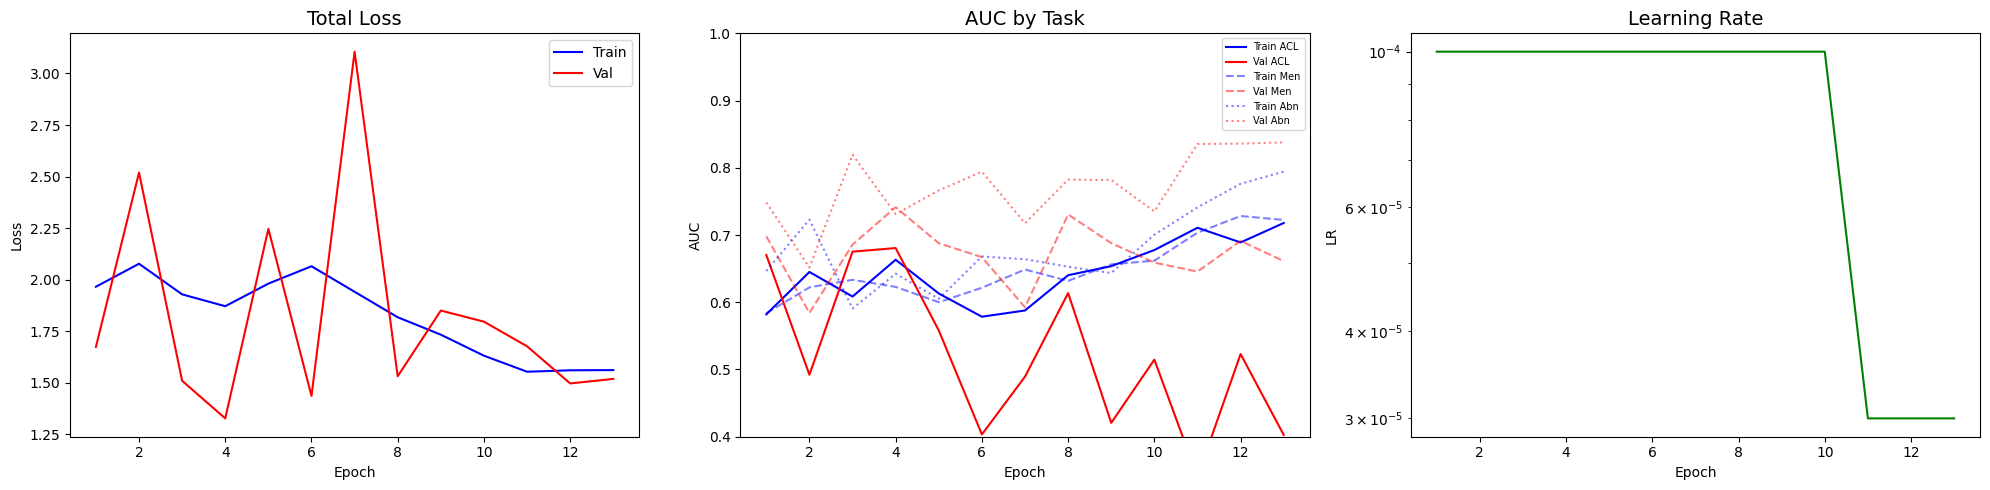

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val')
axes[0].set_title('Total Loss', fontsize=14)
axes[0].legend()
axes[0].set_ylabel('Loss')

# AUCs
axes[1].plot(epochs_range, history['train_auc_acl'], 'b-', label='Train ACL')
axes[1].plot(epochs_range, history['val_auc_acl'], 'r-', label='Val ACL')
axes[1].plot(epochs_range, history['train_auc_men'], 'b--', alpha=0.5, label='Train Men')
axes[1].plot(epochs_range, history['val_auc_men'], 'r--', alpha=0.5, label='Val Men')
axes[1].plot(epochs_range, history['train_auc_abn'], 'b:', alpha=0.5, label='Train Abn')
axes[1].plot(epochs_range, history['val_auc_abn'], 'r:', alpha=0.5, label='Val Abn')
axes[1].set_title('AUC by Task', fontsize=14)
axes[1].legend(fontsize=7)
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.4, 1.0)

# LR
axes[2].plot(epochs_range, history['lr'], 'g-')
axes[2].set_title('Learning Rate', fontsize=14)
axes[2].set_yscale('log')
axes[2].set_ylabel('LR')

for ax in axes:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/training_history_v12.png', dpi=150)
plt.show()

# Cell 12: Final Evaluation (All Tasks)

In [14]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))
model.eval()

val_loss, val_aucs, val_labels, val_probs = validate(model, val_loader, device)

# Find optimal thresholds for each task
for task, title in [('acl', 'ACL'), ('meniscus', 'Meniscus'), ('abnormal', 'Abnormal')]:
    fpr, tpr, thresholds = roc_curve(val_labels[task], val_probs[task])
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    best_thr = thresholds[best_idx]
    print(f"{title}: Optimal threshold={best_thr:.4f} (J={youden_j[best_idx]:.4f}, Sens={tpr[best_idx]:.3f}, Spec={1-fpr[best_idx]:.3f})")

label_names = ['Normal', 'Tear']

print('\n' + '=' * 60)
print('RESULTS — V12 (Multi-Task MRNet)')
print('=' * 60)
print(f'ACL AUC:      {val_aucs["acl"]:.4f}')
print(f'Meniscus AUC: {val_aucs["meniscus"]:.4f}')
print(f'Abnormal AUC: {val_aucs["abnormal"]:.4f}')
composite = SEL_WEIGHT_ACL*val_aucs["acl"] + SEL_WEIGHT_MEN*val_aucs["meniscus"] + SEL_WEIGHT_ABN*val_aucs["abnormal"]
print(f'Composite:    {composite:.4f}')

for task, title in [('acl', 'ACL'), ('meniscus', 'Meniscus'), ('abnormal', 'Abnormal')]:
    print(f'\n--- {title}: Default threshold (0.5) ---')
    preds = [1 if p >= 0.5 else 0 for p in val_probs[task]]
    print(classification_report(val_labels[task], preds, target_names=label_names, digits=3))

Validating:   0%|          | 0/188 [00:00<?, ?it/s]

ACL: Optimal threshold=0.3758 (J=0.3836, Sens=0.692, Spec=0.691)
Meniscus: Optimal threshold=0.4170 (J=0.4301, Sens=0.630, Spec=0.800)
Abnormal: Optimal threshold=0.8071 (J=0.4381, Sens=0.529, Spec=0.909)

RESULTS — V12 (Multi-Task MRNet)
ACL AUC:      0.6806
Meniscus AUC: 0.7414
Abnormal AUC: 0.7312
Composite:    0.7090

--- ACL: Default threshold (0.5) ---
              precision    recall  f1-score   support

      Normal      0.811     0.866     0.838       149
        Tear      0.310     0.231     0.265        39

    accuracy                          0.734       188
   macro avg      0.561     0.548     0.551       188
weighted avg      0.707     0.734     0.719       188


--- Meniscus: Default threshold (0.5) ---
              precision    recall  f1-score   support

      Normal      0.708     0.843     0.770       115
        Tear      0.647     0.452     0.532        73

    accuracy                          0.691       188
   macro avg      0.678     0.648     0.651       1

# Cell 13: Confusion Matrices (All Tasks)

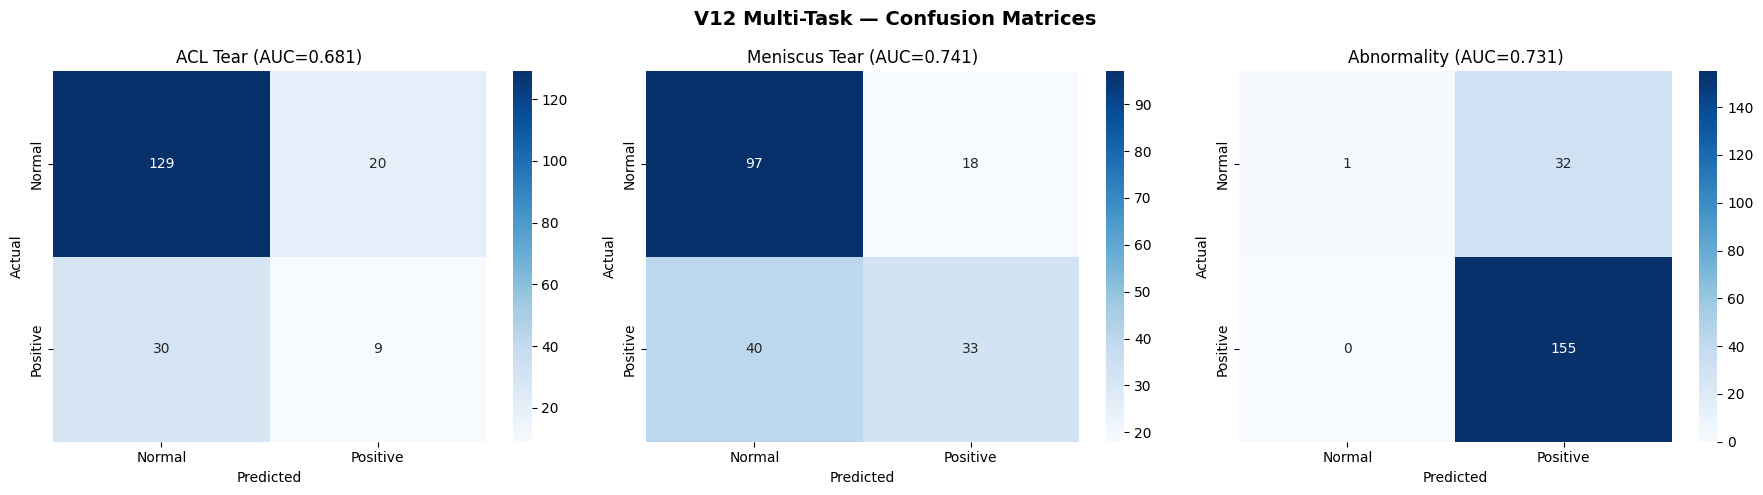

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, task, title in zip(axes,
    ['acl', 'meniscus', 'abnormal'],
    ['ACL Tear', 'Meniscus Tear', 'Abnormality']):
    preds = [1 if p >= 0.5 else 0 for p in val_probs[task]]
    cm = confusion_matrix(val_labels[task], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Positive'], yticklabels=['Normal', 'Positive'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title} (AUC={val_aucs[task]:.3f})')

plt.suptitle('V12 Multi-Task — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix_v12.png', dpi=150)
plt.show()